In [19]:
from astropy.table import Table, join
from matplotlib import pyplot as plt
import numpy as np
from astropy import units
from astropy.coordinates import SkyCoord, ICRS, Galactic
from astropy.coordinates import CartesianRepresentation, CartesianDifferential, SphericalRepresentation, SphericalDifferential
from scipy.interpolate import interp1d, LinearNDInterpolator
from scipy import odr, stats, integrate
from scipy.optimize import curve_fit
from tqdm import tqdm
import astropy.units as u
import matplotlib as mpl
import pandas as pd

#mpl.rcParams.update({# Use mathtext, not LaTeX
#                     'text.usetex': False,
#                     # Use the Computer modern font
#                     'font.family': 'serif',
#                     'font.serif': 'cmr10',
#                     'mathtext.fontset': 'cm',
#                     # Use ASCII minus
#                     'axes.unicode_minus': False,})
#axislabelsize = 22
#mpl.rcParams.update({'xtick.labelsize':axislabelsize})
#mpl.rcParams.update({'ytick.labelsize':axislabelsize})

plt.style.use('stefan.mplstyle')

In [32]:
#data = Table.read("HSTCOS_paper.csv")
#wds = data[data['mass_paper'] > 0.8].copy()
#wds

df = pd.read_csv('../data/tyler/WDMS_total_ages_correct_models_cut_down.csv')

# Rotate ICRS proper motions to Galactic frame
coords = SkyCoord(
    ra=df['ra'].values * u.deg,
    dec=df['dec'].values * u.deg,
    pm_ra_cosdec=df['pmra'].values * u.mas / u.yr,
    pm_dec=df['pmdec'].values * u.mas / u.yr,
    frame='icrs'
)
gal = coords.galactic
pm_l_cosb = gal.pm_l_cosb.to(u.mas / u.yr).value
pm_b      = gal.pm_b.to(u.mas / u.yr).value

# km/s: v = 4.74047 * mu[mas/yr] * d[kpc]
d_kpc = 1.0 / df['wtd_par'].values  # wtd_par in mas
v_l_helio = 4.74047 * pm_l_cosb * d_kpc
v_b_helio = 4.74047 * pm_b      * d_kpc

# Solar motion correction (Schönrich et al. 2010 via Cheng 2019)
U_sun, V_sun, W_sun = 11.0, 12.0, 7.0  # km/s
l_rad = np.radians(df['l'].values)
b_rad = np.radians(df['b'].values)

v_l_sun = -U_sun * np.sin(l_rad) + V_sun * np.cos(l_rad)
v_b_sun = (-U_sun * np.cos(l_rad) * np.sin(b_rad)
           -V_sun * np.sin(l_rad) * np.sin(b_rad)
           +W_sun * np.cos(b_rad))

df['v_l'] = v_l_helio + v_l_sun
df['v_b'] = v_b_helio + v_b_sun

print(f'sigma_l = {df["v_l"].std():.1f} km/s')
print(f'sigma_b = {df["v_b"].std():.1f} km/s')

df['age_frac_err'] = np.maximum(
    df['tot_age_error_upper'].fillna(np.inf),
    df['tot_age_error_lower'].fillna(np.inf)
) / df['tot_age'].replace(0, np.nan)

mask = (
    (df['age_frac_err'] < 0.20) &
    #(df['phot_bp_rp_excess_factor'] < 1.2) &
    (df['Mass'] > 0.63) &
    (df['spectype'] != '0.0') &
    df['tot_age'].notna() & (df['tot_age'] > 0) &
    df['wtd_par'].notna() & (df['wtd_par'] > 0)
)
wds = df[mask].copy().reset_index(drop=True)

wds = wds[wds.phot_bp_rp_excess_factor > 3 * (0.0059898 + 8.817481e-12*wds.phot_g_mean_mag**7.618399)]

print(f'N = {len(wds)}')
print(f'mass range: {np.min(wds["Mass"]):1.2f}-{np.max(wds["Mass"]):1.2f}, mean:{np.mean(wds["Mass"]):1.2f}')

sigma_l = 37.4 km/s
sigma_b = 27.9 km/s
N = 560
mass range: 0.65-1.30, mean:0.78


In [34]:
len(wds[wds["spec_source"] == "GaiaXP"])

443

In [21]:
list(wds.keys())

['Unnamed: 0',
 'source_id',
 'ref_epoch',
 'ra',
 'ra_error',
 'dec',
 'dec_error',
 'parallax',
 'parallax_error',
 'parallax_over_error',
 'pm',
 'pmra',
 'pmra_error',
 'pmdec',
 'pmdec_error',
 'astrometric_params_solved',
 'ruwe',
 'duplicated_source',
 'phot_g_n_obs',
 'phot_g_mean_flux',
 'phot_g_mean_flux_error',
 'phot_g_mean_flux_over_error',
 'phot_g_mean_mag',
 'phot_bp_n_obs',
 'phot_bp_mean_flux',
 'phot_bp_mean_flux_error',
 'phot_bp_mean_flux_over_error',
 'phot_bp_mean_mag',
 'phot_rp_n_obs',
 'phot_rp_mean_flux',
 'phot_rp_mean_flux_error',
 'phot_rp_mean_flux_over_error',
 'phot_rp_mean_mag',
 'phot_bp_n_contaminated_transits',
 'phot_bp_n_blended_transits',
 'phot_rp_n_contaminated_transits',
 'phot_rp_n_blended_transits',
 'phot_proc_mode',
 'phot_bp_rp_excess_factor',
 'bp_rp',
 'bp_g',
 'g_rp',
 'l',
 'b',
 'ecl_lon',
 'ecl_lat',
 'pairdistance',
 'sep_AU',
 'Sigma18',
 'R_chance_align',
 'meanAV',
 'minAV',
 'maxAV',
 'flag_ext',
 'objid',
 'u',
 'g',
 'r',
 'i

# Calculate vl, vb

In [22]:
#=====================================================================================================
#========= Define some functions =====================================================================
#=====================================================================================================
def gal_pm(ra,dec,pmra,pmdec):
    
    skycoords = SkyCoord(ra*u.deg, dec*u.deg, frame = 'icrs', pm_ra_cosdec = pmra*u.mas/u.yr, pm_dec= pmdec*u.mas/u.yr)
    l = (skycoords.galactic.l.to(u.deg)).value
    b = (skycoords.galactic.b.to(u.deg)).value
    pm_l = (skycoords.galactic.pm_l_cosb.to(u.rad/u.s)).to(u.mas/u.year).value
    pm_b = (skycoords.galactic.pm_b.to(u.rad/u.s)).to(u.mas/u.year).value
    
    return l, b, pm_l, pm_b


def AVR(age): # From Sihao's Paper
    c_u, delta_u, beta_u = 5.78, 26.09, 0.35
    c_v, delta_v, beta_v = 0.68*c_u, 0.68*delta_u, 0.68*beta_u
    c_w, delta_w, beta_w = 3.81, 11.97, 0.6
    sigv_u = np.zeros(len(age))
    sigv_v = np.zeros(len(age))
    sigv_w = np.zeros(len(age))
    
    mask = age <= 7
    sigv_u[mask] = c_u + delta_u*np.power(age[mask]/4, beta_u)
    sigv_v[mask] = c_v + delta_v*np.power(age[mask]/4, beta_v)
    sigv_w[mask] = c_w + delta_w*np.power(age[mask]/4, beta_w)
    
    sigv_u[(age > 7) & (age<=10)] = (c_u + delta_u*np.power(7/4, beta_u) + (66.07 - c_u - 
                                             delta_u*np.power(7/4, beta_u))*(age[(age > 7) & (age<=10)]-7)/3)
    sigv_v[(age > 7) & (age<=10)] = (c_v + delta_v*np.power(7/4, beta_v) + (0.64*66.07-c_v - 
                                             delta_v*np.power(7/4, beta_v))*(age[(age > 7) & (age<=10)]-7)/3)
    sigv_w[(age > 7) & (age<=10)] = (c_w + delta_w*np.power(7/4, beta_w) + (34.07-c_w - 
                                             delta_w*np.power(7/4, beta_w))*(age[(age > 7) & (age<=10)]-7)/3)
    
    sigv_u[age > 10] = 66.07
    sigv_v[(age > 10)] = 0.64*66.07
    sigv_w[(age > 10)] = 34.07
    
    return sigv_u, sigv_v, sigv_w
#=====================================================================================================

l, b, pm_l, pm_b = gal_pm(wds['ra'].to_numpy(), wds['dec'].to_numpy(), wds['pmra'].to_numpy(), wds['pmdec'].to_numpy())

# Matrices for Conversion between U,V,W and l,b,r see Sihao Cheng's 2019 paper (or 2020 can't remember)
Ms = np.zeros((len(l), 3,3))
Ms_T = np.zeros((len(l), 3,3))
for i in range(len(l)):
    Ms[i] = np.array([[np.sin(l[i]*np.pi/180.0), -np.sin(b[i]*np.pi/180.0)*np.cos(l[i]*np.pi/180.0), np.cos(b[i]*np.pi/180.0)*np.cos(l[i]*np.pi/180.0)],
    [np.cos(l[i]*np.pi/180.0), -np.sin(b[i]*np.pi/180.0)*np.sin(l[i]*np.pi/180.0), np.cos(b[i]*np.pi/180.0)*np.sin(l[i]*np.pi/180.0)],
    [0, np.cos(b[i]*np.pi/180.0), np.sin(b[i]*np.pi/180.0)]])
    Ms_T[i] = np.array([[np.sin(l[i]*np.pi/180.0), -np.sin(b[i]*np.pi/180.0)*np.cos(l[i]*np.pi/180.0), np.cos(b[i]*np.pi/180.0)*np.cos(l[i]*np.pi/180.0)],
    [np.cos(l[i]*np.pi/180.0), -np.sin(b[i]*np.pi/180.0)*np.sin(l[i]*np.pi/180.0), np.cos(b[i]*np.pi/180.0)*np.sin(l[i]*np.pi/180.0)],
    [0, np.cos(b[i]*np.pi/180.0), np.sin(b[i]*np.pi/180.0)]]).transpose()


wd_ages = wds['tot_age']
wd_tcs = wds['cool_age']
vl,vb = wds['v_l'], wds['v_b']

# Check to make sure distribution is roughly centered at 0
print(np.nanmedian(vl), np.nanmedian(vb))


-4.524303092329773 -1.8743424418030918


In [23]:
# Poisson Errors
p_errors = Table.read('../data/poisson_errors.csv')
p_err_low = interp1d(np.concatenate([p_errors['N'], [1000]]), np.concatenate([p_errors['e_Poisson_lower'], [np.sqrt(1000)]]))
p_err_up = interp1d(np.concatenate([p_errors['N'], [1000]]), np.concatenate([p_errors['e_Poisson_upper'], [np.sqrt(1000)]]))

# Check Expectation

In [24]:
def get_expected_dist(cool_ages, ages, Ms, Ms_T, N, N_merg = 1, fm = 0):
    # This function generates many copies of the same system with a fraction of the systems having a delay from a merger (fm)
    # This takes awhile to run but can provide a more accurate shape of the vel dist
    vl = np.array([])
    vb = np.array([])
    zero = np.zeros(len(ages))
    centers = np.zeros((len(ages), 2))
    if fm != 0:
        for j in tqdm(range(N_merg)):
            delays = np.zeros(len(ages))
            where_delay = np.random.choice(np.arange(len(ages)), int(len(ages)*fm))
            delays[where_delay] = np.random.random(len(where_delay))*5
            # a distribution of delays from Temmink+20 with some negative delays
#             delays[where_delay] = np.random.choice(samples, len(ages[where_delay]))*(ages - cool_ages)[where_delay]

            delays[np.where(ages+delays < 0)] = -ages[np.where(ages+delays < 0)]
            sigv_u, sigv_v, sigv_w = AVR(ages+delays) # delay in Gyr
            M_sig = np.array([[np.square(sigv_u),zero,zero],
                              [zero,np.square(sigv_v),zero],
                              [zero,zero,np.square(sigv_w)]]).T
            covs = np.matmul(np.matmul(Ms_T, M_sig), Ms)[:,0:2,0:2]
            for i in range(len(ages)): # run over every object
                new_vl, new_vb = np.random.multivariate_normal(centers[i], cov = covs[i], size = N).T

                vl = np.append(vl, new_vl)
                vb = np.append(vb, new_vb)
    else:
        sigv_u, sigv_v, sigv_w = AVR(ages)
        M_sig = np.array([[np.square(sigv_u),zero,zero],
                          [zero,np.square(sigv_v),zero],
                          [zero,zero,np.square(sigv_w)]]).T
        covs = np.matmul(np.matmul(Ms_T, M_sig), Ms)[:,0:2,0:2]
        for i in range(len(ages)): # run over every object
            new_vl, new_vb = np.random.multivariate_normal(centers[i], cov = covs[i], size = N).T

            vl = np.append(vl, new_vl)
            vb = np.append(vb, new_vb)        
    return vl, vb # return array of vls and vbs that is NxNxlen(ras) long
#==============================================================================================================================
def get_expected_dist_mean_sig(cool_ages, ages, Ms, Ms_T, N_merg = 1, fm = 0):
    # This function calculates the mean distrbution given the ages so will always return a Gaussian distribution
    # It also runs faster which is nice, but it gives a not realistic shape to the distribution
    sigl = np.zeros(len(ages))
    sigb = np.zeros(len(ages))    
    zero = np.zeros(len(ages))
    
    for j in tqdm(range(N_merg)):
        delays = np.zeros(len(ages))
        rands = np.random.random(len(ages))
        delays[np.where(rands <= fm)] = np.random.random(len(np.where(rands <= fm)[0]))*5
        
    # a distribution of delays from Temmink+20 with some negative delays
#         delays[np.where(rands <= fm)] = (np.random.choice(samples, len(ages))*(ages - cool_ages))[np.where(rands <= fm)]
        delays[np.where(ages+delays < 0)] = -ages[np.where(ages+delays < 0)[0]]
        sigv_u, sigv_v, sigv_w = AVR(ages+delays) # delay in Gyr
        M_sig = np.array([[np.square(sigv_u),zero,zero],
                          [zero,np.square(sigv_v),zero],
                          [zero,zero,np.square(sigv_w)]]).T

        covs = np.matmul(np.matmul(Ms_T, M_sig), Ms)[:,0:2,0:2]
        sigl = sigl + np.sqrt(covs[:,0,0])
        sigb = sigb + np.sqrt(covs[:,1,1])
    
    return sigl/N_merg, sigb/N_merg

In [25]:
b = np.arange(0,81,10)
fms = np.arange(0, 1.0, 0.2)
# Store the expected distributions in these arrays for each merger fraction
# i.e. for fms[i] the x values for the l coordinate are stored in xs_l[i] and N values are stored in ns_l[i]
xs_l = []
ns_l = []
xs_b = []
ns_b = []
i=0
for fm in fms:
    print("Calculating Expectation for fm = {}\n".format(fm))
    
    # Pick which method to generate the expectation you want to use. The first method generates N copies of each object
    # and draws a random velocity given the age. N_merg decides how many copies of the original system are made with a 
    # number of systems equal to fm*N_merg having their ages increased. I'm not sure this method is the best so I am 
    # using the other...
    #
    # The second option calculates the median Gaussian sigma expected given the ages of the wds. It only uses N_merg
    # which generates N_merg copies of the object with fm*N_merg of them with artificially increased ages.
    
#     vl_expected, vb_expected = get_expected_dist(wd_tcs, wd_ages, Ms, Ms_T, N = 500, N_merg = 100, fm = fm)# OPTION 1
#     n_expected, bins_expected = np.histogram((vl_expected), bins = b, density = True) # w/ OPTION 1

    sigl, sigb = get_expected_dist_mean_sig(wd_tcs, wd_ages, Ms, Ms_T, N_merg = 1000, fm = fm) # OPTION 2
    n_expected, bins_expected = np.histogram(np.abs(np.random.normal(0,np.nanmedian(sigl), int(1e6))), 
                                             bins = np.arange(0,131,1), density = False) # w/ OPTION 2

    x_expected = (bins_expected[:-1] + bins_expected[1:])/2
    n_expected = stats.norm.pdf(x_expected, loc = 0, scale = np.nanmedian(sigl))# w/ OPTION 2

    xs_l.append(x_expected)
    ns_l.append(n_expected)
    
#     n_expected, bins_expected = np.histogram((vb_expected), bins = b, density = True) # w/ OPTION 1
    n_expected, bins_expected = np.histogram(np.abs(np.random.normal(0,np.nanmedian(sigb), int(1e6))), 
                                             bins = np.arange(0,131,1), density = False) # w/ OPTION 2
    n_expected = stats.norm.pdf(x_expected, loc = 0, scale = np.nanmedian(sigb))# w/ OPTION 2
    
    x_expected = (bins_expected[:-1] + bins_expected[1:])/2
    
    xs_b.append(x_expected)
    ns_b.append(n_expected)
    i+=1
    
xs_l = np.array(xs_l)
ns_l = np.array(ns_l)

xs_b = np.array(xs_b)
ns_b = np.array(ns_b)

Calculating Expectation for fm = 0.0



100%|██████████| 1000/1000 [00:06<00:00, 143.71it/s]


Calculating Expectation for fm = 0.2



100%|██████████| 1000/1000 [00:07<00:00, 136.77it/s]


Calculating Expectation for fm = 0.4



100%|██████████| 1000/1000 [00:09<00:00, 109.02it/s]


Calculating Expectation for fm = 0.6000000000000001



100%|██████████| 1000/1000 [00:06<00:00, 152.12it/s]


Calculating Expectation for fm = 0.8



100%|██████████| 1000/1000 [00:04<00:00, 215.37it/s]


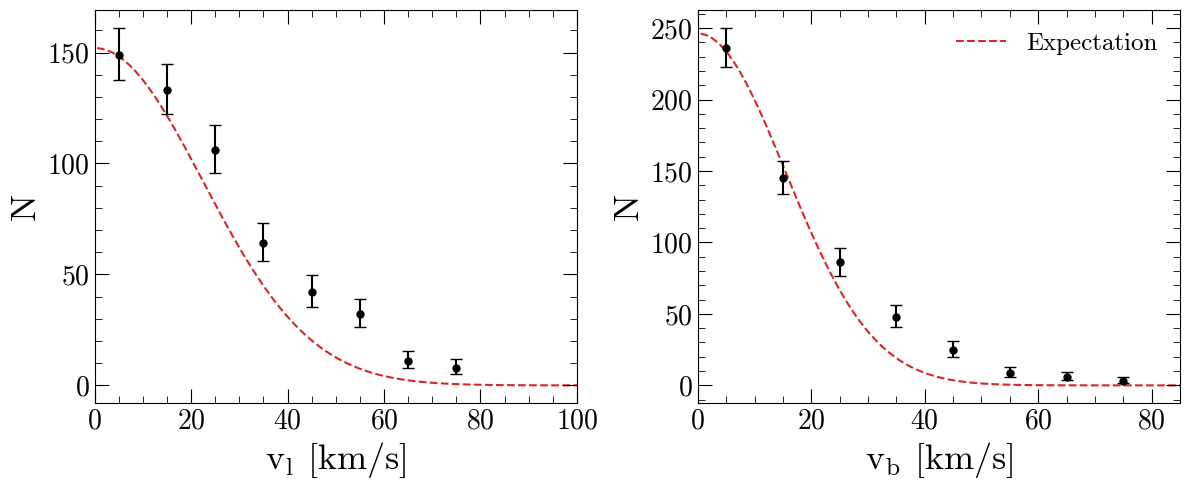

In [30]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
b = np.arange(0,81,10)
n2, bins2 = np.histogram(np.abs(vl), bins = b, density = True)
n2_full, bins2 = np.histogram(np.abs(vl), bins = b, density = False)
x = (bins2[:-1] + bins2[1:])/2
a2 = n2_full/n2
e_n2 = np.sqrt(n2_full)/a2
vl_norm = n2_full[0] # which value to normalise the expected distribution to
# print(n2_full, ns_l)
ax[0].errorbar(x,n2_full,yerr=np.array([p_err_low(n2_full), p_err_up(n2_full)]),fmt = "o", 
               zorder = 1, capsize=4, c="k")#, label = "Cleaned Sample")

n2, bins2 = np.histogram(np.abs(vb), bins = b, density = True)
n2_full, bins2 = np.histogram(np.abs(vb), bins = b, density = False)
xb = (bins2[:-1] + bins2[1:])/2
a2 = n2_full/n2
e_n2 = np.sqrt(n2_full)/a2
vb_norm = n2_full[0] # which value to normalise the expected distribution to
ax[1].errorbar(xb,n2_full,yerr=np.array([p_err_low(n2_full), p_err_up(n2_full)]), fmt = "o", 
               zorder = 1, capsize=4, c="k")#, label = "Cleaned Sample")


colors = ["tab:red","tab:blue","tab:cyan","tab:purple","tab:green", "yellow", 'brown', "magenta", "tab:orange", "k"]
for i in range(1):#len(fms)):
    where=np.where(np.abs(xs_l[i]-x[0]) == np.min(np.abs(xs_l[i]-x[0])))[0][0]
    norm = vl_norm/ns_l[i][where]
    ax[0].plot(xs_l[i] , norm*ns_l[i], "--", color = colors[i], label = "fm = {:.1f}", zorder = 0)
    where=np.where(np.abs(xs_b[i]-xb[0]) == np.min(np.abs(xs_b[i]-xb[0])))[0][0]
    norm = vb_norm/ns_b[i][where]
    ax[1].plot(xs_b[i], norm*ns_b[i], "--", color = colors[i], label = "Expectation", zorder = 0)

ax[0].set_xlim(0,100)
ax[0].set_xlabel(r"$v_l$ [km/s]")
ax[0].set_ylabel("N")
# ax[0].set_yscale('log')
ax[1].legend(framealpha=0)
ax[1].set_xlim(0,85)
ax[1].set_xlabel(r"$v_b$ [km/s]")
ax[1].set_ylabel("N")
# ax[1].set_yscale('log')

# plt.savefig("vel_dist.png", dpi=300)
fig.tight_layout()
fig.savefig("figures_original/vel_dist_mergers.pdf")
plt.show()

/tmp/ipykernel_141954/95264344.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.
  ax[0].errorbar(x_l,nl_full,yerr=yerr_l,fmt = "k.", markersize = 30, color = 'k', #ecolor='xkcd:dark forest green',
/tmp/ipykernel_141954/95264344.py:21: RuntimeWarning: invalid value encountered in divide
  a2 = nb_full/nb
/tmp/ipykernel_141954/95264344.py:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.
  ax[1].errorbar(x_b,nb_full,yerr=yerr_b ,fmt = "k.", markersize = 30, color = 'k', #ecolor='',
/tmp/ipykernel_141954/95264344.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


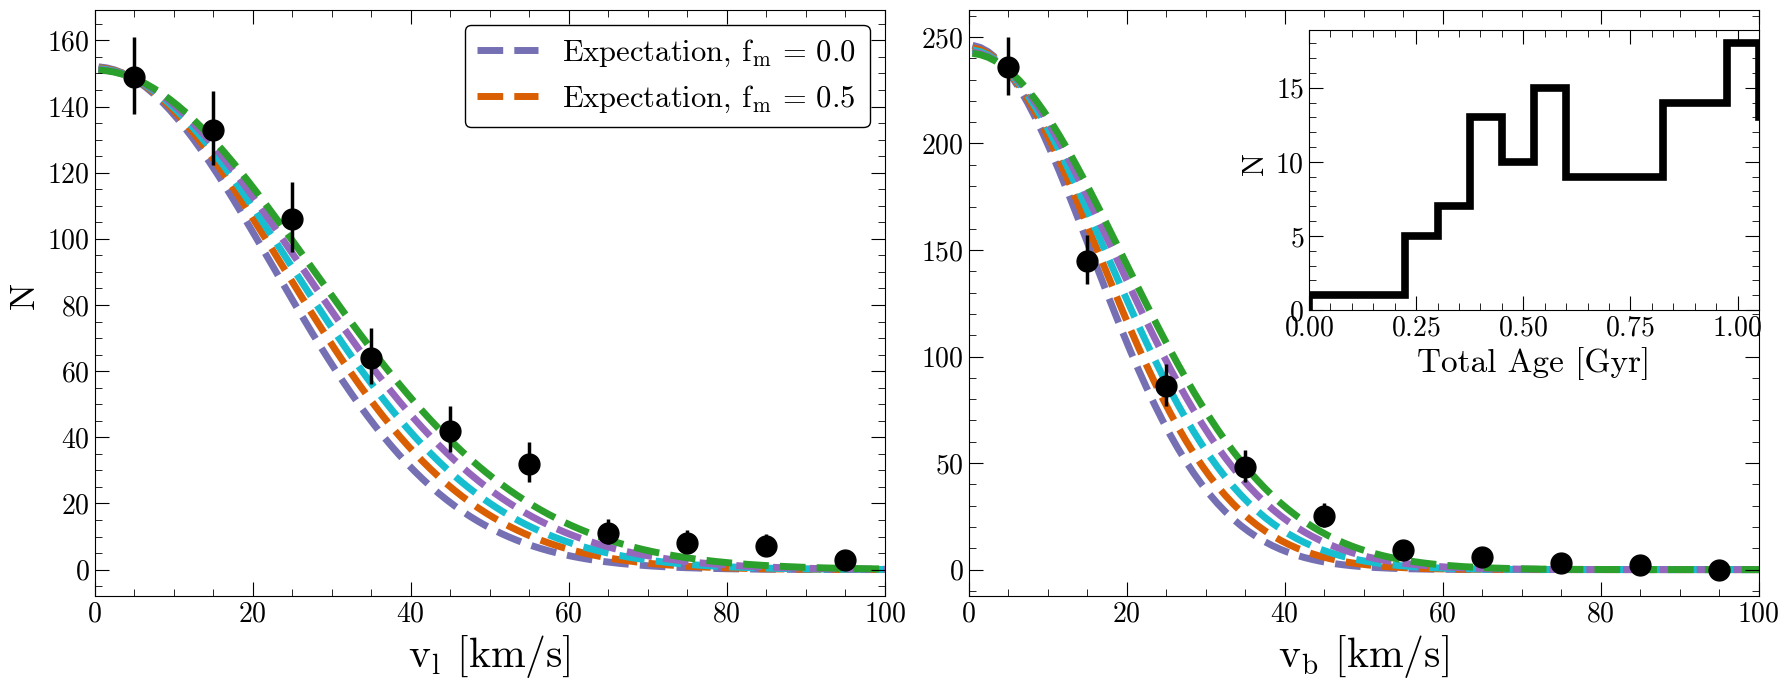

In [9]:
#adapted version from tyler for paper

fig, ax = plt.subplots(1,2, figsize=(18, 7))

b = np.arange(0,101,10)

nl, bins_l = np.histogram(np.abs(vl), bins = b, density = True)
nl_full, bins_l = np.histogram(np.abs(vl), bins = b, density = False)
x_l = (bins_l[:-1] + bins_l[1:])/2
a = nl_full/nl
e_nl = np.sqrt(nl_full)/a
vl_norm = nl_full[0] # which value to normalise the expected distribution to
yerr_l = np.array([p_err_low(nl_full), p_err_up(nl_full)])

ax[0].errorbar(x_l,nl_full,yerr=yerr_l,fmt = "k.", markersize = 30, color = 'k', #ecolor='xkcd:dark forest green',
               elinewidth = 2.5, zorder = 1)

nb, bins_b = np.histogram(np.abs(vb), bins = b, density = True)
nb_full, bins_b = np.histogram(np.abs(vb), bins = b, density = False)
x_b = (bins_b[:-1] + bins_b[1:])/2
a2 = nb_full/nb
e_nb = np.sqrt(nb_full)/a2
vb_norm = nb_full[0] # which value to normalise the expected distribution to
yerr_b = np.array([p_err_low(nb_full), p_err_up(nb_full)])

ax[1].errorbar(x_b,nb_full,yerr=yerr_b ,fmt = "k.", markersize = 30, color = 'k', #ecolor='', 
               elinewidth = 2.5, zorder = 1)#, label = "Cleaned Sample")


colors = ['#7570b3',"#d95f02","tab:cyan","tab:purple","tab:green", "yellow", 'brown', "magenta", "tab:orange", "k"]
for i in range(len(fms)):
    where=np.where(np.abs(xs_l[i]-x[0]) == np.min(np.abs(xs_l[i]-x[0])))[0][0]
    norm = vl_norm/ns_l[i][where]
    ax[0].plot(xs_l[i] , norm*ns_l[i], "--", color = colors[i], zorder = 0, linewidth=5.0) # label = "Expected velocity distribution", 
    where=np.where(np.abs(xs_b[i]-xb[0]) == np.min(np.abs(xs_b[i]-xb[0])))[0][0]
    norm = vb_norm/ns_b[i][where]
    ax[1].plot(xs_b[i], norm*ns_b[i], "--", color = colors[i], label = "Expectation", zorder = 0, linewidth=5)

#point for legend
ax[0].plot([-2,-1], [0,0], "--", color = colors[0], label = r'Expectation, $f_{\rm m}$ = 0.0 ', zorder = 0, linewidth=5)
ax[0].plot([-2,-1], [0,0], "--", color = colors[1], label = r'Expectation, $ f_{\rm m}$ = 0.5', zorder = 0, linewidth=5)

left, bottom, width, height = [0.73, 0.55, 0.25, 0.4]
ax2 = fig.add_axes([left, bottom, width, height])

ax2.hist(wds['tot_age'], 20,
                            density = False, histtype = 'step', linewidth=5.5,
                            color ='k', range =(0,1.5))

ax2.set_xlabel(r'Total Age [Gyr]', fontsize = 24)
ax2.set_ylabel(r' $N$', fontsize = 22)
ax2.set_xlim(0,1.05)

ax[0].set_xlim(0,100)
ax[0].set_xlabel(r'$v_l$ [km/s]', fontsize = 30)
ax[0].set_ylabel(r' $N$', fontsize = 26)
# ax[0].set_yscale('log')
ax[0].legend(fontsize = 22)
ax[1].set_xlim(0,100)
ax[1].set_xlabel(r'$v_b$ [km/s]', fontsize = 30)
#ax[1].set_ylabel(r' $N$', fontsize = 26)
# ax[1].set_yscale('log')
plt.tight_layout()

# plt.savefig("vel_dist.png", dpi=300)
plt.savefig("vel_dist_v5.pdf", dpi=300)

plt.show()

In [10]:
print(x_l, x_b, nl_full, nb_full, yerr_l, yerr_b)
#print(xs_l[0], norm*ns_l[0])
#plt.scatter(xs_l[0], norm*ns_l[0])

[ 5. 15. 25. 35. 45. 55. 65. 75. 85. 95.] [ 5. 15. 25. 35. 45. 55. 65. 75. 85. 95.] [149 133 106  64  42  32  11   8   7   3] [236 145  86  48  25   9   6   3   2   0] [[11.15832895 10.77356848 10.12428518  7.972       6.45        5.63
   3.266       2.768       2.581       1.633     ]
 [12.12279561 11.75616848 11.13748518  9.038       7.53        6.72
   4.42        3.95        3.77        2.918     ]] [[13.25046402 11.06213883  9.254       6.9         4.97        2.943
   2.38        1.633       1.292       0.        ]
 [14.11633069 12.03113883 10.292       7.98        6.07        4.11
   3.584       2.918       2.638       1.841     ]]


In [11]:
#maybe overcomplicating... 
#for fm = 0 

where=np.where(np.abs(xs_l[0]-x[0]) == np.min(np.abs(xs_l[0]-x[0])))[0][0]
norm_l = vl_norm/ns_l[0][where]

where=np.where(np.abs(xs_b[0]-xb[0]) == np.min(np.abs(xs_b[0]-xb[0])))[0][0]
norm_b = vb_norm/ns_b[0][where]

y_interp_l = np.interp(x_l, xs_l[0], norm_l*ns_l[0])
y_interp_b = np.interp(x_b, xs_b[0], norm_b*ns_b[0])

print(y_interp_l, y_interp_b)

#vl
y_err = yerr_l[1]

residuals = nl_full - y_interp_l

chi_squared = np.sum(residuals**2 / y_err**2)
chi_squared_red = chi_squared/11
print(chi_squared, chi_squared_red)


#vb
y_errb = yerr_b[1]

residuals_b = nb_full - y_interp_b

chi_squared_b = np.sum(residuals_b**2 / y_errb**2)
chi_squared_red_b = chi_squared_b/11
print(chi_squared_b, chi_squared_red_b)


[1.48262474e+02 1.21522941e+02 8.16417532e+01 4.49565915e+01
 2.02909046e+01 7.50648093e+00 2.27613630e+00 5.65701062e-01
 1.15239805e-01 1.92417586e-02] [2.33563442e+02 1.53944137e+02 6.68774283e+01 1.91493382e+01
 3.61397609e+00 4.49545271e-01 3.68567836e-02 1.99166506e-03
 7.09363649e-05 1.66522928e-06]
43.5927851721225 3.9629804701929543
38.245439281324025 3.4768581164840024


In [12]:
#maybe overcomplicating... 
#for fm = 0.5

where=np.where(np.abs(xs_l[1]-x[0]) == np.min(np.abs(xs_l[1]-x[0])))[0][0]
norm_l = vl_norm/ns_l[1][where]
where=np.where(np.abs(xs_b[1]-xb[0]) == np.min(np.abs(xs_b[1]-xb[0])))[0][0]
norm_b = vb_norm/ns_b[1][where]

y_interp_l = np.interp(x_l, xs_l[0], norm_l*ns_l[0])
y_interp_b = np.interp(x_b, xs_b[0], norm_b*ns_b[0])

print(y_interp_l, y_interp_b)

#vl
y_err = yerr_l[1]

residuals = nl_full - y_interp_l

chi_squared = np.sum(residuals**2 / y_err**2)
chi_squared_red = chi_squared/11
print(chi_squared, chi_squared_red)

#vb
y_errb = yerr_b[1]

residuals_b = nb_full - y_interp_b

chi_squared_b = np.sum(residuals_b**2 / y_errb**2)
chi_squared_red_b = chi_squared_b/11
print(chi_squared_b, chi_squared_red_b)


[1.56450110e+02 1.28233915e+02 8.61503314e+01 4.74392710e+01
 2.14114480e+01 7.92101828e+00 2.40183348e+00 5.96941296e-01
 1.21603800e-01 2.03043641e-02] [2.46991278e+02 1.62794566e+02 7.07222898e+01 2.02502560e+01
 3.82174781e+00 4.75390155e-01 3.89757231e-02 2.10616821e-03
 7.50145794e-05 1.76096526e-06]
39.05925912053688 3.550841738230625
37.961424547349175 3.451038595213561


# Determine Age Distribution that can Reproduce Vel. Dist.

In [13]:
# Calculate the expected velocity dispersion (sigl, sigb) for each discrete age bin.
# get_expected_dist_mean_sig returns per-object sigma values; we take the median across
# the sample so each age bin collapses to a single representative Gaussian.
age = np.arange(0.25,10.5,0.25)
b = np.arange(0,101,10)
sig_vl = []
sig_vb = []
for a in age:
    sigl, sigb = get_expected_dist_mean_sig(wd_tcs, np.zeros(len(wds))+a, Ms, Ms_T, N_merg = 100, fm = 0)
    sig_vl.append(sigl)                           
    sig_vb.append(sigb)

sig_vl = np.array(sig_vl)
sig_vb = np.array(sig_vb)

# Observed sample histograms used as the fitting target
n2, bins2 = np.histogram(np.abs(vl), bins = b, density = True)
n2_full_l, bins2 = np.histogram(np.abs(vl), bins = b, density = False)
xl = (bins2[:-1] + bins2[1:])/2
a2 = n2_full_l/n2
e_n2_l = np.sqrt(n2_full_l)/a2
vl_first = n2_full_l[2]

n2, bins2 = np.histogram(np.abs(vb), bins = b, density = True)
n2_full_b, bins2 = np.histogram(np.abs(vb), bins = b, density = False)
xb = (bins2[:-1] + bins2[1:])/2
a2 = n2_full_b/n2
e_n2_b = np.sqrt(n2_full_b)/a2
vb_first = n2_full_b[2]

# Build Gaussian template for each age bin as proper probability masses.
# For the folded distribution |N(0, sigma)|, P(a <= |v| <= b) = 2*(Phi(b/s) - Phi(a/s)).
# Using CDF differences rather than pdf(bin_centre) avoids the density-vs-mass mismatch
# that is most severe for narrow Gaussians (young ages) where sigma ~ bin width.
# Shape: (n_age_bins, n_velocity_bins)
ns_l = np.zeros((len(sig_vl), len(xl)))
ns_b = np.zeros((len(sig_vb), len(xb)))
for i in range(len(sig_vl)):
    sigma_l = np.nanmedian(sig_vl[i])
    sigma_b = np.nanmedian(sig_vb[i])
    ns_l[i] = 2 * (stats.norm.cdf(b[1:], 0, sigma_l) - stats.norm.cdf(b[:-1], 0, sigma_l))
    ns_b[i] = 2 * (stats.norm.cdf(b[1:], 0, sigma_b) - stats.norm.cdf(b[:-1], 0, sigma_b))

# Row-normalise to condition on |v| < 100 km/s (handles any truncation for large sigma).
ns_l = ns_l / ns_l.sum(axis=1, keepdims=True)
ns_b = ns_b / ns_b.sum(axis=1, keepdims=True)

100%|██████████| 100/100 [00:00<00:00, 2811.21it/s]
/tmp/ipykernel_141954/820868827.py:27: RuntimeWarning: invalid value encountered in divide
  a2 = n2_full_b/n2


In [14]:
# Fit the observed velocity distributions with a weighted mixture of the age-bin Gaussians.
# weights[i] is proportional to the fraction of the sample at age[i].
# N_runs independent fits with randomised starting weights to check robustness.
N_runs = 100
popts = np.zeros((N_runs, len(age)))

# Joint fitting target: l and b histograms concatenated
comp = np.concatenate([n2_full_l, n2_full_b])
error = p_err_up(comp)  # upper Poisson errors used as sigma

N_l = n2_full_l.sum()  # total observed counts, used to set model amplitude
N_b = n2_full_b.sum()

lower_bounds = np.array([1,10,20,20,20,20,20,20,10,5,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1])

for i in range(len(popts)):
    def f(xs, *weights):
        # weighted sum of normalised Gaussian templates; since each row of ns_l sums to 1,
        # val_l.sum() == sum(weights), so the amplitude is set purely by N_l
        val_l = np.sum((ns_l.T*weights).T, axis=0)
        val_b = np.sum((ns_b.T*weights).T, axis=0)
        return np.concatenate([N_l * val_l / val_l.sum(), N_b * val_b / val_b.sum()])

    # initialise within bounds so curve_fit starts in a valid region
    weights = lower_bounds + np.random.random(len(age)) * (100 - lower_bounds)
    popt, pcov = curve_fit(f, np.concatenate([xl, xb]), comp, p0=weights,
                       sigma=error, absolute_sigma=True,
                       bounds=(0, 400))
    popts[i] = popt

<>:36: SyntaxWarning: invalid escape sequence '\%'
<>:36: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_141954/410170621.py:36: SyntaxWarning: invalid escape sequence '\%'
  ax3.set_ylabel("\% of Sample")
/tmp/ipykernel_141954/410170621.py:28: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax3.plot(age, (popts[i]/np.sum(popts[i])*100), "r-", alpha = 0.5,color = "r",lw = 1)


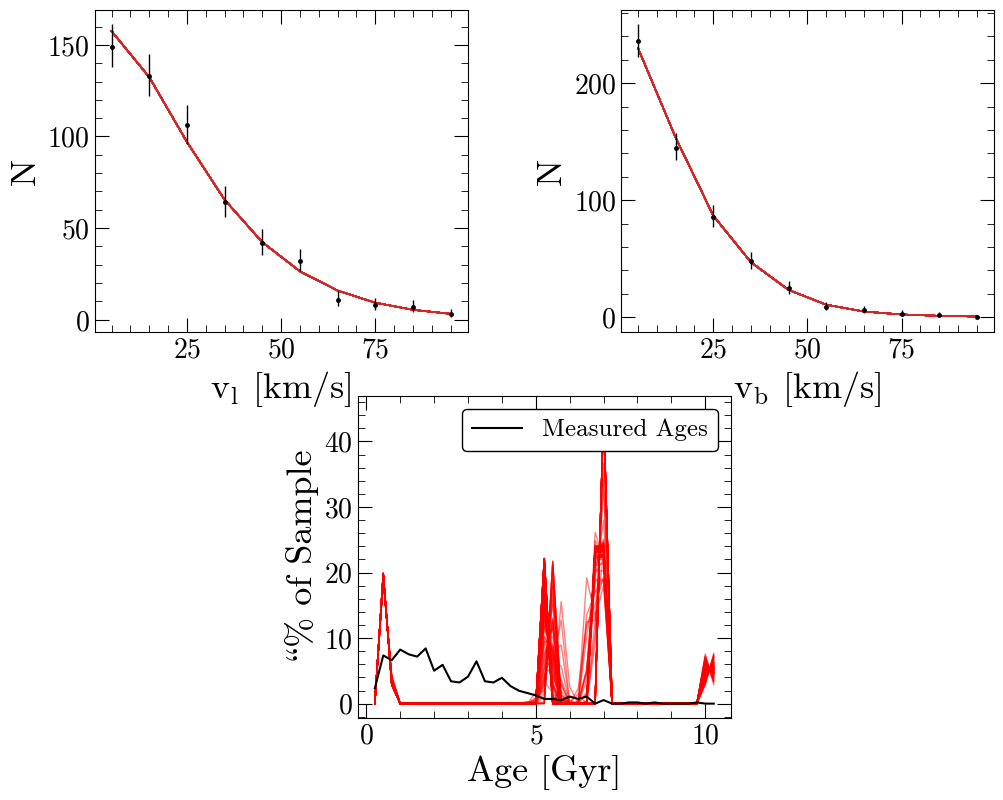

In [15]:
fig = plt.figure(figsize = (2.5*6,2.3*4))
gs = fig.add_gridspec(2,9)
ax1 = fig.add_subplot(gs[0, 1:4])
ax2 = fig.add_subplot(gs[0, 5:8])
ax3 = fig.add_subplot(gs[1, 3:6])

ax1.errorbar(xl,n2_full_l,yerr=np.array([p_err_low(n2_full_l), p_err_up(n2_full_l)]),
               fmt = "k.", elinewidth = 1, zorder = 1)
ax2.errorbar(xb,n2_full_b,yerr=np.array([p_err_low(n2_full_b), p_err_up(n2_full_b)]),
               fmt = "k.", elinewidth = 1, zorder = 1)

popt = np.median(popts, axis = 0)
error = np.std(popts, axis = 0)

for popt in popts:
    vl_plot = np.sum((ns_l.T*popt).T, axis=0)
    vb_plot = np.sum((ns_b.T*popt).T, axis=0)
    # vl_plot.sum() == sum(popt) because ns_l rows are normalised
    ax1.plot(xl, N_l * vl_plot / vl_plot.sum(), "-", color = "tab:red", zorder = 0, alpha = 0.5,lw=1)
    ax2.plot(xb, N_b * vb_plot / vb_plot.sum(), "-", color = "tab:red", zorder = 0, alpha = 0.5,lw=1)
ax1.set_xlabel("$v_l$ [km/s]")
ax2.set_xlabel("$v_b$ [km/s]")
ax1.set_ylabel("N")
ax2.set_ylabel("N")

# popts[i]/sum(popts[i]) is the inferred age mixing fraction for run i — 41 points, one per age bin
for i in range(N_runs):
    ax3.plot(age, (popts[i]/np.sum(popts[i])*100), "r-", alpha = 0.5,color = "r",lw = 1)

# Bin the measured ages using edges centred on each age value so x_expected == age (41 points)
n, bins_expected = np.histogram(wd_ages, bins=np.append(age - 0.125, age[-1] + 0.125))
x_expected = (bins_expected[:-1] + bins_expected[1:])/2

ax3.plot(x_expected, n/sum(n)*100, "k-", label = "Measured Ages")
ax3.set_xlabel("Age [Gyr]")
ax3.set_ylabel("\% of Sample")
# ax3.set_ylim(-2,45)
ax3.legend()

#plt.savefig("vel_fit.png", dpi = 300)
plt.show()

In [16]:
sum(n/len(wd_ages)*100), sum((popts[i]/np.sum(popts[i])*100))

(np.float64(99.64285714285714), np.float64(100.0))

In [17]:
popts[50]

array([5.25651843e-07, 2.99836667e+02, 5.05410640e+01, 3.89455899e-03,
       5.85167857e-04, 5.57050699e-04, 4.43420740e-04, 3.72865921e-06,
       2.71760967e-03, 2.54938897e-03, 5.55181738e-03, 9.74200865e-03,
       1.13763044e-02, 1.29067779e-03, 4.01668664e-02, 1.88466570e-04,
       2.19025257e-01, 6.36690205e-01, 2.68468289e-03, 3.60513271e-04,
       2.80487302e+02, 2.42234293e-05, 1.02491430e-03, 2.39101207e-02,
       2.07623585e-03, 2.09774395e-03, 3.99865538e+02, 3.39753396e+02,
       1.96644988e-04, 5.48546027e-04, 3.03188941e-05, 9.63586463e-06,
       1.41415499e-12, 5.10673524e-09, 2.77511688e-06, 4.42763752e-05,
       1.74931330e-04, 7.09693925e-05, 7.55072432e-06, 8.92637924e+01,
       7.18221205e+01])